[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Curs%2001/20241010%20Volatility%20Estimators.ipynb)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


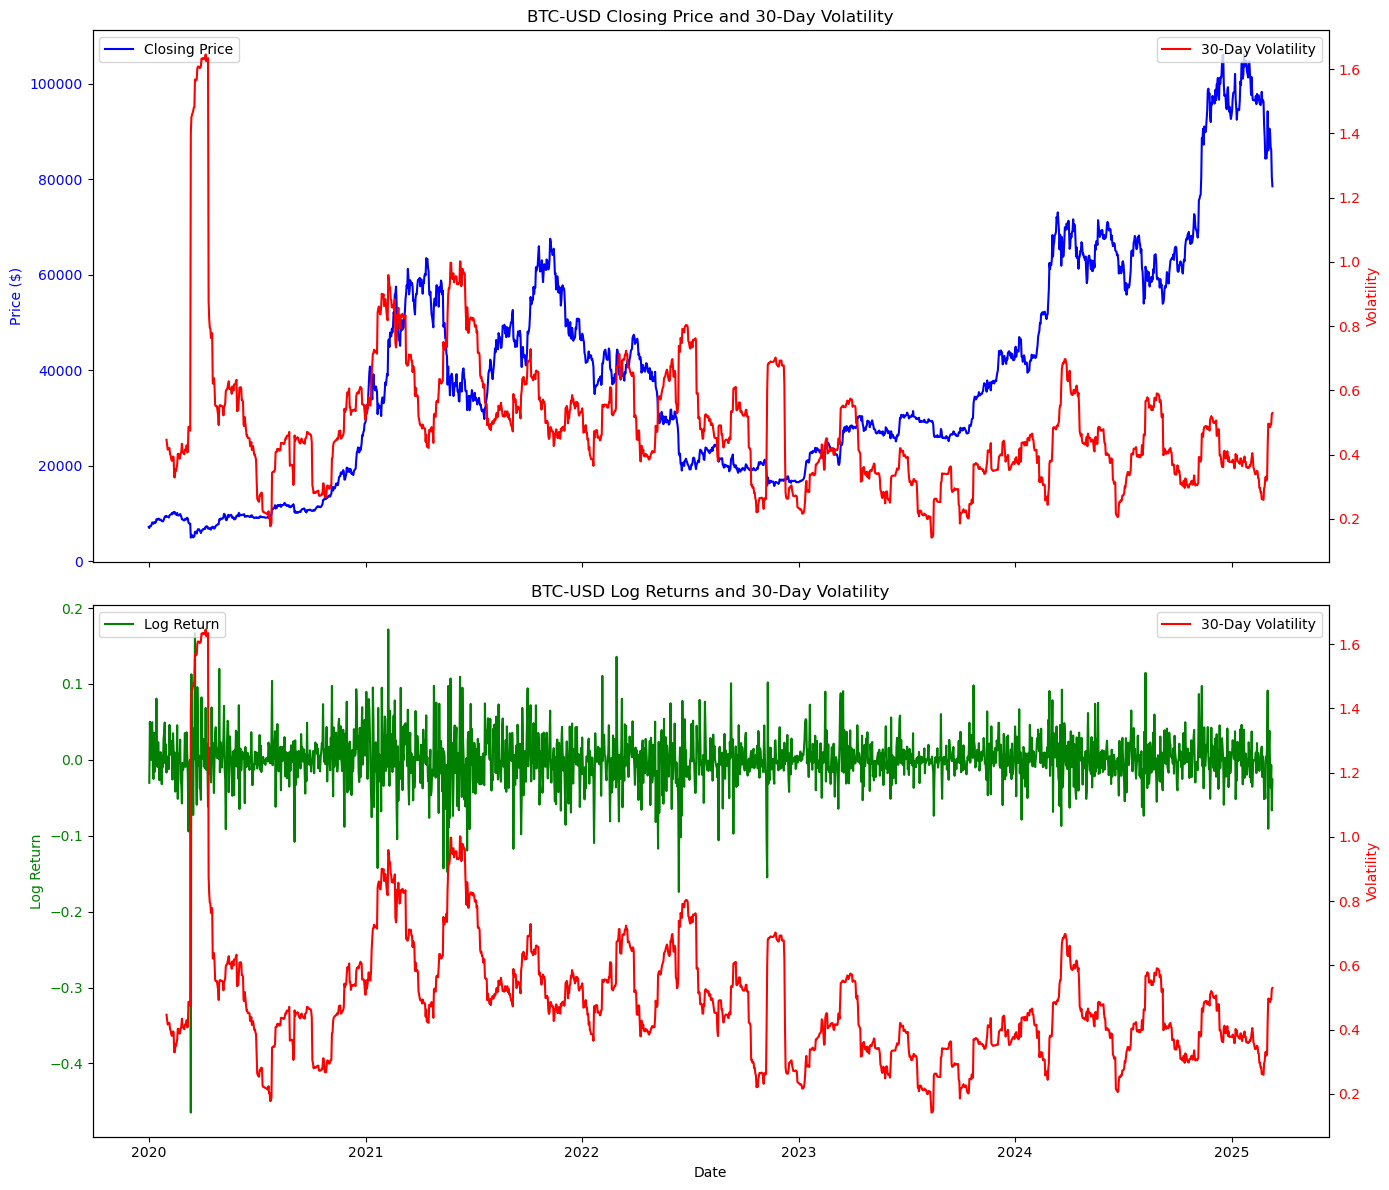

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# Step 1: Fetch historical stock data (AAPL as an example)
ticker = 'BTC-USD'
start_date = '2020-01-01'
end_date = '2025-03-11'
data = yf.download(ticker, start=start_date, end=end_date)

# Step 2: Calculate daily log returns
data['Log Return'] = np.log(data['Close'] / data['Close'].shift(1))

# Step 3: Calculate historical volatility (rolling standard deviation)
volatility_window = 30  # 30-day rolling volatility
data['Volatility'] = data['Log Return'].rolling(window=volatility_window).std() * np.sqrt(252)  # Annualized volatility

# Step 4: Increase font size for better readability
#plt.rcParams.update({'font.size': 14})  # Increase the font size globally

# Create a 2-panel plot: top panel for price & volatility, bottom panel for returns & volatility
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)  # Increase figure size for better visibility

# Panel 1: Plot closing price and volatility
ax1.plot(data.index, data['Close'], label='Closing Price', color='blue')
ax1.set_ylabel('Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title(f'{ticker} Closing Price and {volatility_window}-Day Volatility')

# Create a second y-axis for volatility on the first panel
ax1b = ax1.twinx()
ax1b.plot(data.index, data['Volatility'], label=f'{volatility_window}-Day Volatility', color='red')
ax1b.set_ylabel('Volatility', color='red')
ax1b.tick_params(axis='y', labelcolor='red')

# Legends for panel 1
ax1.legend(loc='upper left')
ax1b.legend(loc='upper right')

# Panel 2: Plot log returns and volatility
ax2.plot(data.index, data['Log Return'], label='Log Return', color='green')
ax2.set_ylabel('Log Return', color='green')
ax2.set_xlabel('Date')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_title(f'{ticker} Log Returns and {volatility_window}-Day Volatility')

# Create a second y-axis for volatility on the second panel
ax2b = ax2.twinx()
ax2b.plot(data.index, data['Volatility'], label=f'{volatility_window}-Day Volatility', color='red')
ax2b.set_ylabel('Volatility', color='red')
ax2b.tick_params(axis='y', labelcolor='red')

# Legends for panel 2
ax2.legend(loc='upper left')
ax2b.legend(loc='upper right')

# Tight layout and save figure with transparent background
plt.tight_layout()
plt.savefig('price_returns_volatility.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


[*********************100%***********************]  1 of 1 completed


<Figure size 1400x1200 with 0 Axes>

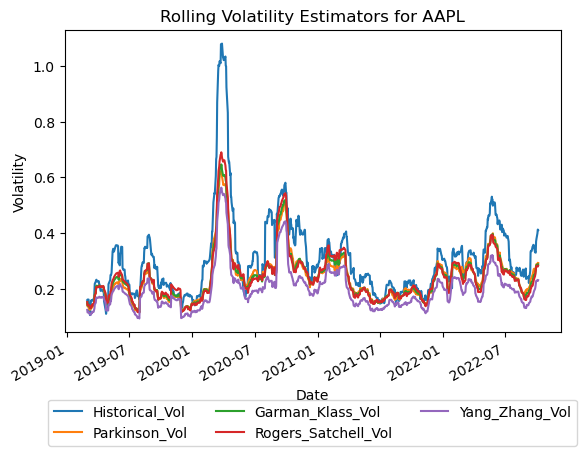

In [8]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Volatility estimators

# Historical Volatility (based on close prices)
def historical_volatility(returns, window):
    return returns.rolling(window=window).std() * np.sqrt(252)

# Parkinson's Estimator (requires high and low prices)
def parkinson_volatility(high, low, window):
    return np.sqrt((1 / (4 * np.log(2))) * (np.log(high / low) ** 2).rolling(window=window).mean()) * np.sqrt(252)

# Garman-Klass Estimator (requires open, high, low, and close prices)
def garman_klass_volatility(open_prices, high, low, close, window):
    log_hl = np.log(high / low)
    log_co = np.log(close / open_prices)
    return np.sqrt((0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2).rolling(window=window).mean()) * np.sqrt(252)

# Rogers-Satchell Estimator (requires open, high, low, and close prices)
def rogers_satchell_volatility(open_prices, high, low, close, window):
    log_high_open = np.log(high / open_prices)
    log_low_open = np.log(low / open_prices)
    log_high_close = np.log(high / close)
    log_low_close = np.log(low / close)
    
    return np.sqrt((log_high_open * log_high_close + log_low_open * log_low_close).rolling(window=window).mean()) * np.sqrt(252)

# Yang-Zhang Estimator based on the image formula
def yang_zhang_volatility(open_prices, high, low, close, prev_close, window):
    # Step 1: Overnight variance (σ²_O)
    log_oc = np.log(open_prices / prev_close)
    overnight_variance = (log_oc - log_oc.rolling(window=window).mean())**2
    sigma_o2 = overnight_variance.rolling(window=window).mean()

    # Step 2: Open-to-Close variance (σ²_C)
    log_co = np.log(close / open_prices)
    close_variance = (log_co - log_co.rolling(window=window).mean())**2
    sigma_c2 = close_variance.rolling(window=window).mean()

    # Step 3: Rogers-Satchell variance (σ²_RS)
    rs_variance = rogers_satchell_volatility(open_prices, high, low, close, window)
    sigma_rs2 = rs_variance ** 2

    # Step 4: Weighting factor k (typically set to 0.34)
    k = 0.34

    # Step 5: Combine to get the Yang-Zhang volatility
    yz_volatility = np.sqrt(sigma_o2 + k * sigma_c2 + (1 - k) * sigma_rs2)

    return yz_volatility

# Download historical data from Yahoo Finance using yfinance
ticker = 'AAPL'  # You can replace 'AAPL' with any other ticker symbol
data = yf.download(ticker, start='2019-01-01', end='2022-10-06')

# Compute daily log returns for historical volatility
data['Prev_Close'] = data['Close'].shift(1)
data.dropna(inplace=True)  # Drop NaN values due to shifting
returns = np.log(data['Close'] / data['Prev_Close'])

# Set the rolling window size (e.g., 20 days)
window_size = 20

# Compute rolling volatilities for the entire dataset
data['Historical_Vol'] = historical_volatility(returns, window=window_size)
data['Parkinson_Vol'] = parkinson_volatility(data['High'], data['Low'], window=window_size)
data['Garman_Klass_Vol'] = garman_klass_volatility(data['Open'], data['High'], data['Low'], data['Close'], window=window_size)
data['Rogers_Satchell_Vol'] = rogers_satchell_volatility(data['Open'], data['High'], data['Low'], data['Close'], window=window_size)
data['Yang_Zhang_Vol'] = yang_zhang_volatility(data['Open'], data['High'], data['Low'], data['Close'], data['Prev_Close'], window=window_size)

# Drop NaN values caused by the rolling window calculation
data.dropna(inplace=True)

# Plot the volatilities
plt.figure(figsize=(14, 12))
ax = data[['Historical_Vol', 'Parkinson_Vol', 'Garman_Klass_Vol', 'Rogers_Satchell_Vol', 'Yang_Zhang_Vol']].plot()

# Customizations
plt.title(f'Rolling Volatility Estimators for {ticker}')
plt.ylabel('Volatility')

# Adjust layout to make room for the legend below the plot
plt.subplots_adjust(bottom=0.25)

# Place the legend outside the plot, at the bottom
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

# Save the plot with a transparent background
plt.savefig('volatility_estimators_corrected.png', dpi=300, transparent=True, bbox_inches='tight')

# Show the plot
plt.show()
